In [ ]:
#Install required libraries

!pip -q install pandas numpy matplotlib scikit-learn wfdb pillow openpyxl ucimlrepo

In [ ]:
#Imports

import os
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import wfdb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# Download UCI Heart Disease Dataset

from ucimlrepo import fetch_ucirepo

# Fetch Cleveland Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Dataset loaded successfully!
Features shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [ ]:
# Dataset inspection

print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nDATA TYPES ")
print(X.dtypes)

print("\nMISSING VALUES ")
print(X.isnull().sum())

print("\nSTATISTICAL SUMMARY ")
display(X.describe())

Number of rows: 303
Number of features: 13

DATA TYPES 
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

MISSING VALUES 
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

STATISTICAL SUMMARY 


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [ ]:
# Create a single dataframe

df_heart = X.copy()

# Target is originally 0, 1, 2, 3, 4
df_heart["target"] = y.values.ravel()

print("Shape:", df_heart.shape)
display(df_heart.head())

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
#  Convert target to binary

df_heart["target_binary"] = (df_heart["target"] > 0).astype(int)

print("Target distribution:")
print(df_heart["target_binary"].value_counts())

print("\n0 = No Heart Disease")
print("1 = Heart Disease")

Target distribution:
target_binary
0    164
1    139
Name: count, dtype: int64

0 = No Heart Disease
1 = Heart Disease


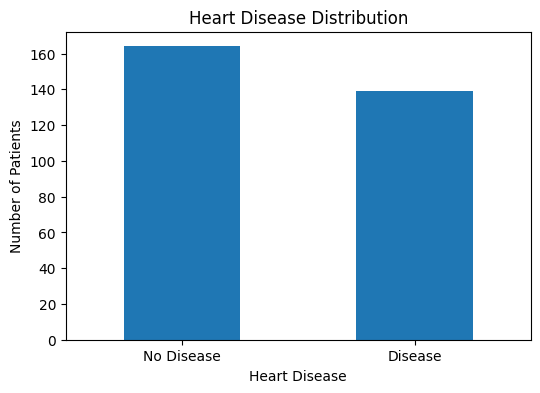

In [ ]:
# Target distribution

plt.figure(figsize=(6, 4))

df_heart["target_binary"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)
plt.show()

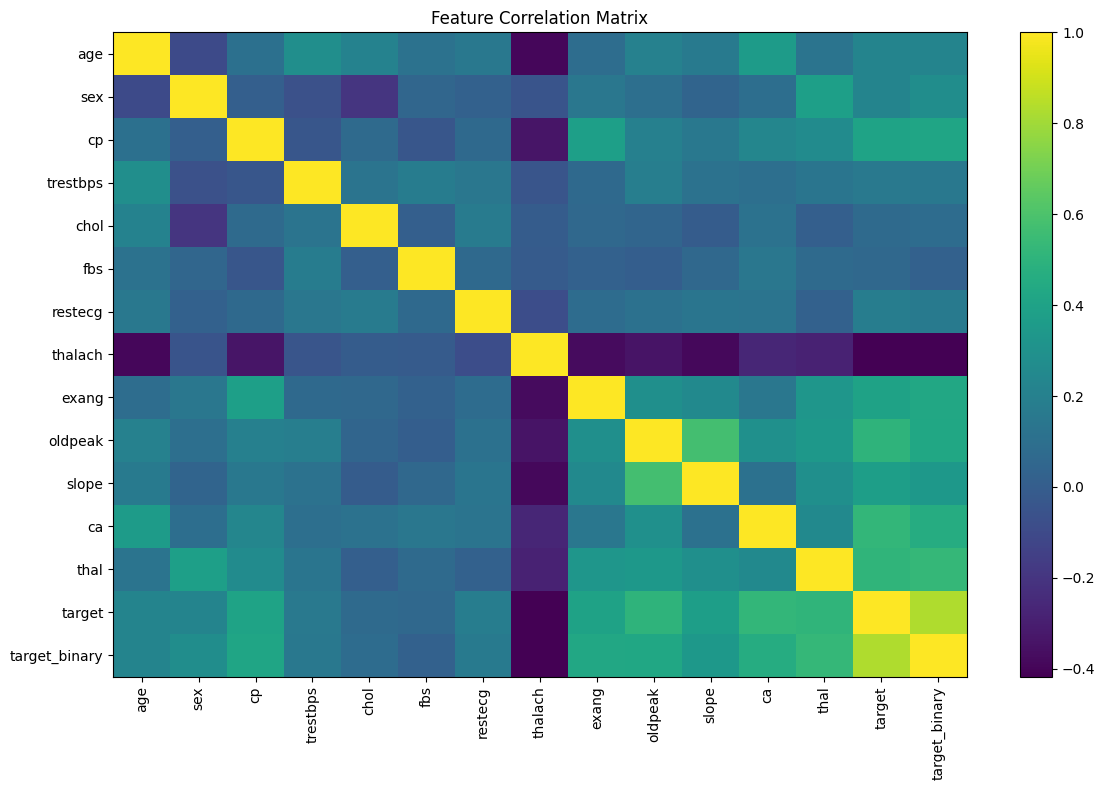

In [ ]:
# Correlation matrix

plt.figure(figsize=(12, 8))

correlation = df_heart.corr(numeric_only=True)

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Prepare data for machine learning

X = df_heart.drop(columns=["target", "target_binary"])
y = df_heart["target_binary"]

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [ ]:
#  Machine Learning Pipeline

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(max_iter=1000)
    )
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
# Model evaluation

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8689
ROC-AUC: 0.9513

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



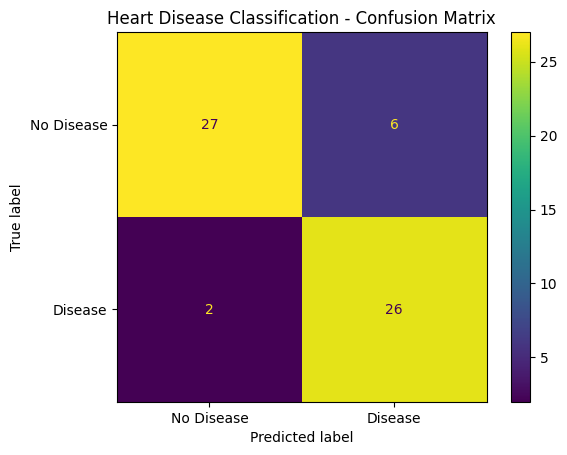

In [ ]:
#  Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Heart Disease Classification - Confusion Matrix")
plt.show()

In [ ]:
# Load MIT-BIH ECG signal

record_name = "100"

record = wfdb.rdrecord(
    record_name,
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    record_name,
    "atr",
    pn_dir="mitdb"
)

print("ECG record loaded successfully!")

print("\nSignal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)

ECG record loaded successfully!

Signal shape: (650000, 2)
Sampling frequency: 360
Number of samples: 650000
Number of channels: 2


In [ ]:
# ECG metadata

print("----- ECG INFORMATION -----")
print("Sampling frequency:", record.fs, "Hz")
print("Number of channels:", record.n_sig)
print("Signal length:", record.sig_len)
print("Channel names:", record.sig_name)

print("\n----- ANNOTATION INFORMATION -----")
print("Number of annotations:", len(annotation.sample))
print("Annotation symbols:", annotation.symbol[:30])

----- ECG INFORMATION -----
Sampling frequency: 360 Hz
Number of channels: 2
Signal length: 650000
Channel names: ['MLII', 'V5']

----- ANNOTATION INFORMATION -----
Number of annotations: 2274
Annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


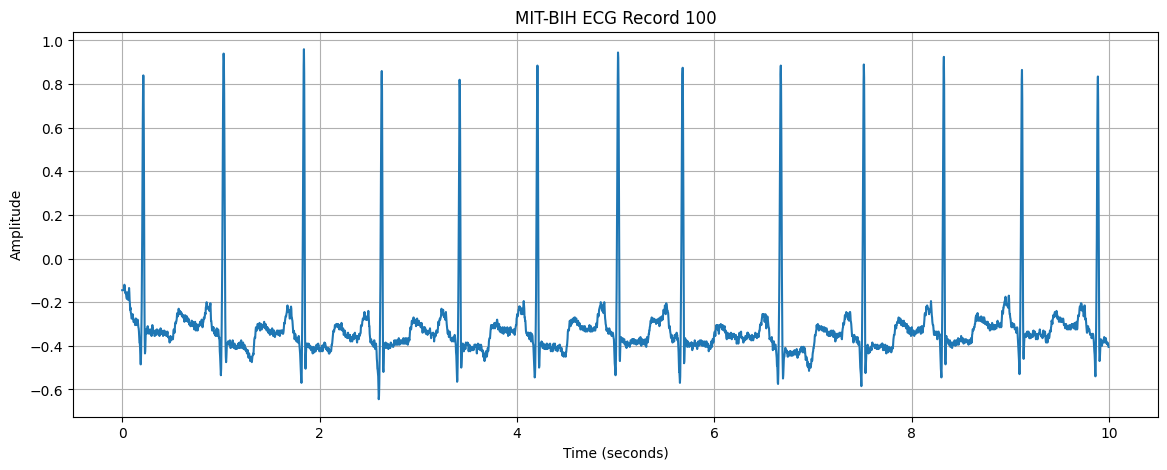

In [ ]:
# Plot ECG

fs = record.fs

# Plot first 10 seconds
seconds = 10
samples = int(seconds * fs)

ecg_signal = record.p_signal[:samples, 0]

time = np.arange(samples) / fs

plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal)

plt.title("MIT-BIH ECG Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

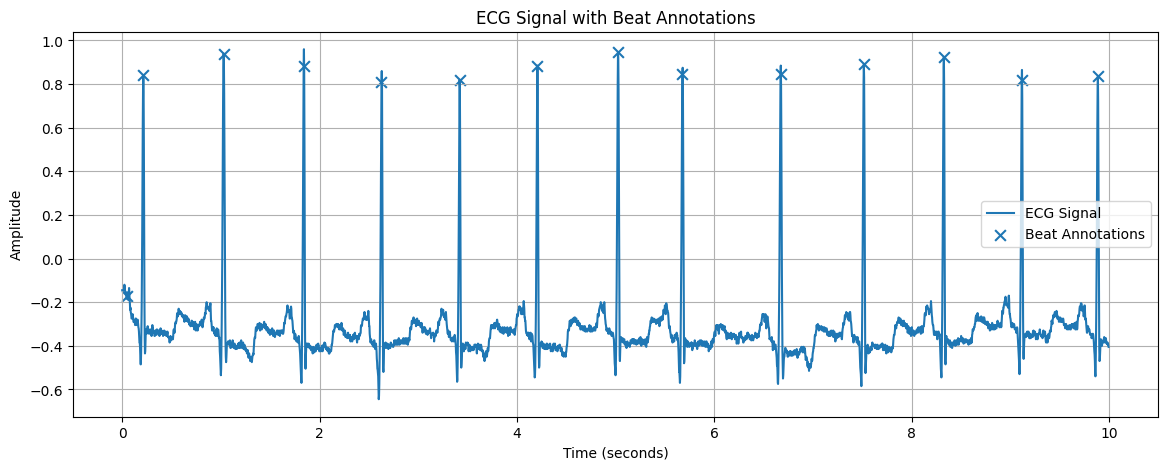

Annotations in first 10 seconds:
[(np.str_('+'), np.float64(0.05)), (np.str_('N'), np.float64(0.21388888888888888)), (np.str_('N'), np.float64(1.0277777777777777)), (np.str_('N'), np.float64(1.8388888888888888)), (np.str_('N'), np.float64(2.6277777777777778)), (np.str_('N'), np.float64(3.4194444444444443)), (np.str_('N'), np.float64(4.208333333333333)), (np.str_('N'), np.float64(5.025)), (np.str_('A'), np.float64(5.677777777777778)), (np.str_('N'), np.float64(6.6722222222222225)), (np.str_('N'), np.float64(7.516666666666667)), (np.str_('N'), np.float64(8.327777777777778)), (np.str_('N'), np.float64(9.116666666666667)), (np.str_('N'), np.float64(9.88888888888889))]


In [ ]:
# ECG with annotations

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    ecg_signal,
    label="ECG Signal"
)

# Select annotations within first 10 seconds
annotation_indices = annotation.sample < samples

ann_samples = annotation.sample[annotation_indices]
ann_symbols = np.array(annotation.symbol)[annotation_indices]

# Only keep annotations that fall inside plotted segment
valid = ann_samples < samples

plt.scatter(
    ann_samples[valid] / fs,
    record.p_signal[ann_samples[valid], 0],
    marker="x",
    s=60,
    label="Beat Annotations"
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

print("Annotations in first 10 seconds:")
print(list(zip(ann_symbols, ann_samples / fs)))

In [ ]:
# RR interval calculation

beat_samples = annotation.sample

# Difference between consecutive beats
rr_intervals_samples = np.diff(beat_samples)

# Convert samples to seconds
rr_intervals_seconds = rr_intervals_samples / fs

print("First 10 RR intervals:")
print(rr_intervals_seconds[:10])

print("\nMean RR interval:",
      round(np.mean(rr_intervals_seconds), 4),
      "seconds")

print("Mean heart rate:",
      round(60 / np.mean(rr_intervals_seconds), 2),
      "BPM")

First 10 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]

Mean RR interval: 0.7943 seconds
Mean heart rate: 75.54 BPM


In [ ]:
# HRV statistics

mean_rr = np.mean(rr_intervals_seconds)
std_rr = np.std(rr_intervals_seconds)

# RMSSD
rmssd = np.sqrt(
    np.mean(
        np.diff(rr_intervals_seconds) ** 2
    )
)

mean_hr = 60 / mean_rr

print("HEART RATE / HRV")
print("Mean RR interval:", round(mean_rr, 4), "seconds")
print("SD of RR intervals:", round(std_rr, 4), "seconds")
print("RMSSD:", round(rmssd, 4), "seconds")
print("Average Heart Rate:", round(mean_hr, 2), "BPM")

HEART RATE / HRV
Mean RR interval: 0.7943 seconds
SD of RR intervals: 0.0506 seconds
RMSSD: 0.0647 seconds
Average Heart Rate: 75.54 BPM


In [ ]:
#  Synthetic clinical note

clinical_note = """
Patient ID: P001

The patient is a 58 year old male presenting with chest pain
and shortness of breath during physical activity. The patient
has a history of high blood pressure and elevated cholesterol.
Resting ECG shows abnormal findings. The patient reports
occasional dizziness and fatigue. Further cardiovascular
evaluation is recommended.
"""

print(clinical_note)


Patient ID: P001

The patient is a 58 year old male presenting with chest pain
and shortness of breath during physical activity. The patient
has a history of high blood pressure and elevated cholesterol.
Resting ECG shows abnormal findings. The patient reports
occasional dizziness and fatigue. Further cardiovascular
evaluation is recommended.



In [ ]:
#  Text cleaning and tokenization

import re

# Convert to lowercase
text = clinical_note.lower()

# Remove punctuation
text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

# Tokenize
tokens = text.split()

print("Tokens:")
print(tokens)

print("\nNumber of tokens:", len(tokens))

Tokens:
['patient', 'id', 'p001', 'the', 'patient', 'is', 'a', '58', 'year', 'old', 'male', 'presenting', 'with', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'during', 'physical', 'activity', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'blood', 'pressure', 'and', 'elevated', 'cholesterol', 'resting', 'ecg', 'shows', 'abnormal', 'findings', 'the', 'patient', 'reports', 'occasional', 'dizziness', 'and', 'fatigue', 'further', 'cardiovascular', 'evaluation', 'is', 'recommended']

Number of tokens: 51


In [ ]:
#  Stopword removal

stopwords = {
    "the", "a", "an", "is", "are", "of",
    "and", "with", "has", "have", "to",
    "during", "in", "for", "on", "this",
    "patient", "reports"
}

filtered_tokens = [
    word for word in tokens
    if word not in stopwords
]

print("Filtered tokens:")
print(filtered_tokens)

Filtered tokens:
['id', 'p001', '58', 'year', 'old', 'male', 'presenting', 'chest', 'pain', 'shortness', 'breath', 'physical', 'activity', 'history', 'high', 'blood', 'pressure', 'elevated', 'cholesterol', 'resting', 'ecg', 'shows', 'abnormal', 'findings', 'occasional', 'dizziness', 'fatigue', 'further', 'cardiovascular', 'evaluation', 'recommended']


In [ ]:
#  Word frequency analysis

word_frequency = Counter(filtered_tokens)

print("Most common words:")

for word, count in word_frequency.most_common(15):
    print(word, ":", count)

Most common words:
id : 1
p001 : 1
58 : 1
year : 1
old : 1
male : 1
presenting : 1
chest : 1
pain : 1
shortness : 1
breath : 1
physical : 1
activity : 1
history : 1
high : 1


In [ ]:
#  Simple keyword extraction

medical_keywords = [
    "chest",
    "pain",
    "shortness",
    "breath",
    "blood",
    "pressure",
    "cholesterol",
    "ecg",
    "dizziness",
    "fatigue",
    "cardiovascular"
]

found_keywords = [
    word for word in medical_keywords
    if word in tokens
]

print("Medical keywords found:")
print(found_keywords)

Medical keywords found:
['chest', 'pain', 'shortness', 'breath', 'blood', 'pressure', 'cholesterol', 'ecg', 'dizziness', 'fatigue', 'cardiovascular']


Chest X-ray downloaded successfully!
Image format: PNG
Image size: (3000, 2919)
Image mode: P


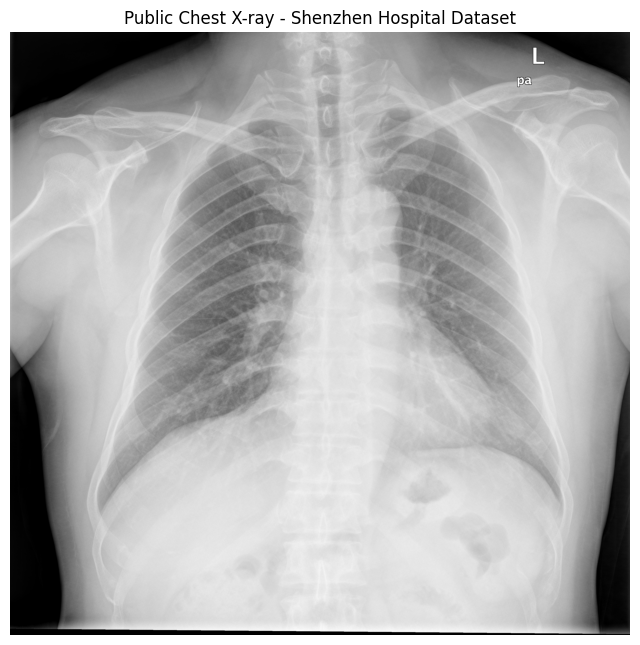

In [ ]:
# Load a real public chest X-ray

import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# Public normal chest X-ray from the Shenzhen Hospital CXR dataset
image_url = (
    "https://data.lhncbc.nlm.nih.gov/public/"
    "Tuberculosis-Chest-X-ray-Datasets/"
    "Shenzhen-Hospital-CXR-Set/CXR_png/"
    "CHNCXR_0001_0.png"
)

response = requests.get(image_url)

if response.status_code == 200:
    medical_image = Image.open(BytesIO(response.content))
    print("Chest X-ray downloaded successfully!")
else:
    raise Exception(
        f"Failed to download image. Status code: {response.status_code}"
    )

print("Image format:", medical_image.format)
print("Image size:", medical_image.size)
print("Image mode:", medical_image.mode)

plt.figure(figsize=(8, 8))
plt.imshow(medical_image, cmap="gray")
plt.title("Public Chest X-ray - Shenzhen Hospital Dataset")
plt.axis("off")
plt.show()

Image loaded successfully!
File path: /content/chest_xray.png
Format: PNG
Size: (3000, 2919)
Mode: P


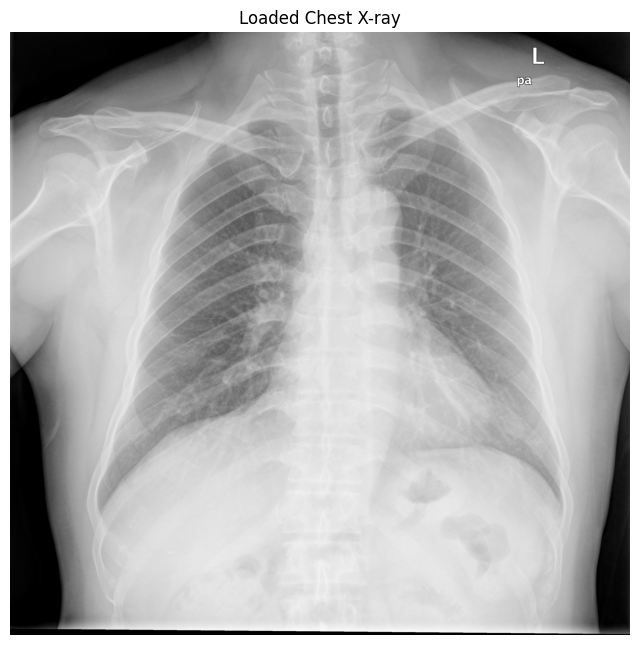

In [ ]:
# Save and reload the medical image

image_path = "/content/chest_xray.png"

# Save image locally
medical_image.save(image_path)

# Reload using Pillow
loaded_image = Image.open(image_path)

print("Image loaded successfully!")
print("File path:", image_path)
print("Format:", loaded_image.format)
print("Size:", loaded_image.size)
print("Mode:", loaded_image.mode)

plt.figure(figsize=(8, 8))
plt.imshow(loaded_image, cmap="gray")
plt.title("Loaded Chest X-ray")
plt.axis("off")
plt.show()

Original size: (3000, 2919)
Resized size: (224, 224)


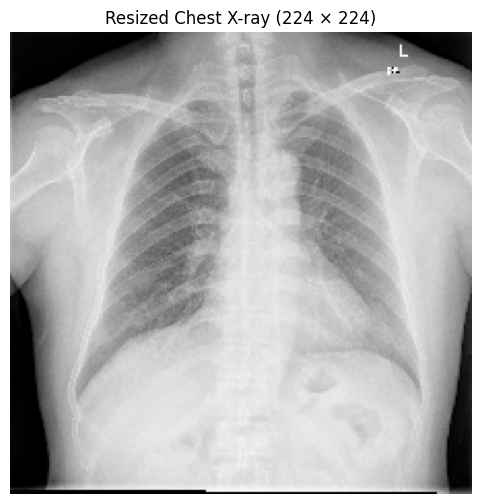

In [ ]:
# Resize medical image

# Resize to a standard size commonly used as input for ML models
resized_image = loaded_image.resize((224, 224))

print("Original size:", loaded_image.size)
print("Resized size:", resized_image.size)

plt.figure(figsize=(6, 6))
plt.imshow(resized_image, cmap="gray")
plt.title("Resized Chest X-ray (224 × 224)")
plt.axis("off")
plt.show()

Before normalization:
Minimum pixel value: 0
Maximum pixel value: 255
Shape: (224, 224)

After normalization:
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Shape: (224, 224)


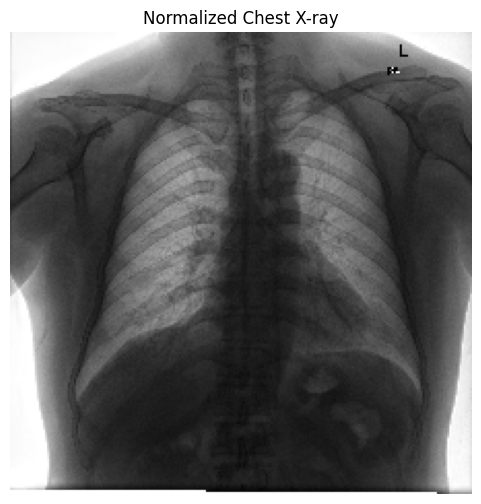

In [ ]:
#  Normalize image pixels

# Convert image to NumPy array
image_data = np.array(resized_image)

print("Before normalization:")
print("Minimum pixel value:", image_data.min())
print("Maximum pixel value:", image_data.max())
print("Shape:", image_data.shape)

# Normalize pixel values from [0, 255] to [0, 1]
normalized_image = image_data.astype(np.float32) / 255.0

print("\nAfter normalization:")
print("Minimum pixel value:", normalized_image.min())
print("Maximum pixel value:", normalized_image.max())
print("Shape:", normalized_image.shape)

# Display normalized image
plt.figure(figsize=(6, 6))
plt.imshow(normalized_image, cmap="gray")
plt.title("Normalized Chest X-ray")
plt.axis("off")
plt.show()

In [ ]:
#  Multimodal Dataset class

class MultimodalDataset:

    def __init__(self):
        self.data = {}
        self.metadata = {}

    def add(self, modality, data, metadata=None):
        self.data[modality] = data
        self.metadata[modality] = metadata or {}

    def summary(self):

        print("=" * 60)
        print("MULTIMODAL DATASET SUMMARY")
        print("=" * 60)

        for modality, data in self.data.items():

            print(f"\nMODALITY: {modality}")
            print("-" * 40)

            if isinstance(data, pd.DataFrame):
                print("Type: DataFrame")
                print("Shape:", data.shape)

            elif isinstance(data, np.ndarray):
                print("Type: NumPy Array")
                print("Shape:", data.shape)

            elif isinstance(data, Image.Image):
                print("Type: PIL Image")
                print("Size:", data.size)

            elif isinstance(data, str):
                print("Type: Text")
                print("Characters:", len(data))

            else:
                print("Type:", type(data))

            print("Metadata:", self.metadata[modality])

In [ ]:
# Generic loader functions

def load_tabular(file_path):
    """
    Load CSV or Excel tabular data.
    """

    extension = Path(file_path).suffix.lower()

    if extension == ".csv":
        data = pd.read_csv(file_path)

    elif extension in [".xls", ".xlsx"]:
        data = pd.read_excel(file_path)

    elif extension == ".json":
        data = pd.read_json(file_path)

    else:
        raise ValueError(
            f"Unsupported tabular format: {extension}"
        )

    return data


def load_text(file_path):
    """
    Load plain text data.
    """

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as file:

        return file.read()


def load_image(file_path):
    """
    Load PNG/JPEG/TIFF images.
    """

    return Image.open(file_path)


def load_ecg(record_name, annotation_type="atr"):
    """
    Load ECG signal and annotations using WFDB.
    """

    record = wfdb.rdrecord(
        record_name,
        pn_dir="mitdb"
    )

    annotation = wfdb.rdann(
        record_name,
        annotation_type,
        pn_dir="mitdb"
    )

    return record, annotation

In [ ]:
# Test image and text loaders

# Text file
text_path = "/content/clinical_note.txt"

with open(
    text_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(clinical_note)

loaded_text = load_text(text_path)

print("TEXT LOADER:")
print(loaded_text)

print("\nIMAGE LOADER:")

loaded_img = load_image(image_path)

print("Size:", loaded_img.size)
print("Mode:", loaded_img.mode)

TEXT LOADER:

Patient ID: P001

The patient is a 58 year old male presenting with chest pain
and shortness of breath during physical activity. The patient
has a history of high blood pressure and elevated cholesterol.
Resting ECG shows abnormal findings. The patient reports
occasional dizziness and fatigue. Further cardiovascular
evaluation is recommended.


IMAGE LOADER:
Size: (3000, 2919)
Mode: P


In [ ]:
#  Create composite medical record

patient_id = "P001"

medical_record = {
    "patient_id": patient_id,

    "tabular": {
        "age": 58,
        "sex": 1,
        "resting_bp": 140,
        "cholesterol": 245,
        "max_heart_rate": 150,
        "exercise_angina": 0
    },

    "text": clinical_note,

    "image": {
        "path": image_path,
        "format": loaded_image.format,
        "size": loaded_image.size
    },

    "signal": {
        "record": "100",
        "sampling_frequency": float(record.fs),
        "channels": record.n_sig,
        "signal_length": record.sig_len
    }
}

print(json.dumps(medical_record, indent=4, default=str))

{
    "patient_id": "P001",
    "tabular": {
        "age": 58,
        "sex": 1,
        "resting_bp": 140,
        "cholesterol": 245,
        "max_heart_rate": 150,
        "exercise_angina": 0
    },
    "text": "\nPatient ID: P001\n\nThe patient is a 58 year old male presenting with chest pain\nand shortness of breath during physical activity. The patient\nhas a history of high blood pressure and elevated cholesterol.\nResting ECG shows abnormal findings. The patient reports\noccasional dizziness and fatigue. Further cardiovascular\nevaluation is recommended.\n",
    "image": {
        "path": "/content/chest_xray.png",
        "format": "PNG",
        "size": [
            3000,
            2919
        ]
    },
    "signal": {
        "record": "100",
        "sampling_frequency": 360.0,
        "channels": 2,
        "signal_length": 650000
    }
}


In [ ]:
# Build unified dataset

dataset = MultimodalDataset()

dataset.add(
    "tabular",
    df_heart,
    {
        "source": "UCI Cleveland Heart Disease",
        "rows": df_heart.shape[0],
        "columns": df_heart.shape[1]
    }
)

dataset.add(
    "text",
    clinical_note,
    {
        "source": "Synthetic Clinical Note",
        "patient_id": patient_id
    }
)

dataset.add(
    "image",
    loaded_image,
    {
        "source": "Synthetic Medical Image",
        "format": loaded_image.format,
        "mode": loaded_image.mode
    }
)

dataset.add(
    "signal",
    record.p_signal,
    {
        "source": "MIT-BIH Arrhythmia Database",
        "record": "100",
        "sampling_frequency": record.fs
    }
)

dataset.summary()

MULTIMODAL DATASET SUMMARY

MODALITY: tabular
----------------------------------------
Type: DataFrame
Shape: (303, 15)
Metadata: {'source': 'UCI Cleveland Heart Disease', 'rows': 303, 'columns': 15}

MODALITY: text
----------------------------------------
Type: Text
Characters: 346
Metadata: {'source': 'Synthetic Clinical Note', 'patient_id': 'P001'}

MODALITY: image
----------------------------------------
Type: PIL Image
Size: (3000, 2919)
Metadata: {'source': 'Synthetic Medical Image', 'format': 'PNG', 'mode': 'P'}

MODALITY: signal
----------------------------------------
Type: NumPy Array
Shape: (650000, 2)
Metadata: {'source': 'MIT-BIH Arrhythmia Database', 'record': '100', 'sampling_frequency': 360}


In [ ]:
#  Automatic file type detection

def detect_and_load(file_path):

    extension = Path(file_path).suffix.lower()

    print("File:", file_path)
    print("Detected format:", extension)

    # Tabular
    if extension in [".csv", ".xls", ".xlsx", ".json"]:
        return load_tabular(file_path)

    # Text
    elif extension in [".txt", ".html", ".xml"]:
        return load_text(file_path)

    # Image
    elif extension in [".png", ".jpg", ".jpeg", ".tiff", ".tif"]:
        return load_image(file_path)

    else:
        raise ValueError(
            f"Unsupported file type: {extension}"
        )

In [ ]:
# Test automatic file detection

result = detect_and_load(
    "/content/synthetic_medical_image.png"
)

print("\nLoaded object type:")
print(type(result))

File: /content/synthetic_medical_image.png
Detected format: .png

Loaded object type:
<class 'PIL.PngImagePlugin.PngImageFile'>


In [ ]:
# Data validation and inspection

def inspect_data(data):

    print("=" * 50)
    print("DATA INSPECTION")
    print("=" * 50)

    # Pandas DataFrame
    if isinstance(data, pd.DataFrame):

        print("Type: Tabular")
        print("Shape:", data.shape)

        print("\nMissing values:")
        print(data.isnull().sum())

        print("\nData types:")
        print(data.dtypes)

        print("\nDuplicate rows:")
        print(data.duplicated().sum())

        print("\nFirst 5 rows:")
        display(data.head())

    # NumPy array
    elif isinstance(data, np.ndarray):

        print("Type: Numerical Array")
        print("Shape:", data.shape)
        print("Minimum:", np.min(data))
        print("Maximum:", np.max(data))
        print("Mean:", np.mean(data))
        print("Standard deviation:", np.std(data))

    # Image
    elif isinstance(data, Image.Image):

        print("Type: Image")
        print("Format:", data.format)
        print("Size:", data.size)
        print("Mode:", data.mode)

    # Text
    elif isinstance(data, str):

        print("Type: Text")
        print("Characters:", len(data))
        print("Words:", len(data.split()))

    else:

        print("Unsupported object type:", type(data))

In [ ]:
# Test inspector

print("TABULAR DATA")
inspect_data(df_heart)

print("\nIMAGE DATA")
inspect_data(loaded_image)

print("\nSIGNAL DATA")
inspect_data(record.p_signal)

print("\nTEXT DATA")
inspect_data(clinical_note)

TABULAR DATA
DATA INSPECTION
Type: Tabular
Shape: (303, 15)

Missing values:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               4
thal             2
target           0
target_binary    0
dtype: int64

Data types:
age                int64
sex                int64
cp                 int64
trestbps           int64
chol               int64
fbs                int64
restecg            int64
thalach            int64
exang              int64
oldpeak          float64
slope              int64
ca               float64
thal             float64
target             int64
target_binary      int64
dtype: object

Duplicate rows:
0

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0



IMAGE DATA
DATA INSPECTION
Type: Image
Format: PNG
Size: (3000, 2919)
Mode: P

SIGNAL DATA
DATA INSPECTION
Type: Numerical Array
Shape: (650000, 2)
Minimum: -2.715
Maximum: 1.435
Mean: -0.24866670384615372
Standard deviation: 0.18157117166295544

TEXT DATA
DATA INSPECTION
Type: Text
Characters: 346
Words: 51


In [ ]:
#  ECG filtering

from scipy.signal import butter, filtfilt

ecg = record.p_signal[:, 0]

fs = record.fs

# Bandpass filter: 0.5 - 40 Hz
lowcut = 0.5
highcut = 40.0

nyquist = fs / 2

low = lowcut / nyquist
high = highcut / nyquist

b, a = butter(
    N=3,
    Wn=[low, high],
    btype="band"
)

filtered_ecg = filtfilt(
    b,
    a,
    ecg
)

print("ECG filtering completed.")

ECG filtering completed.


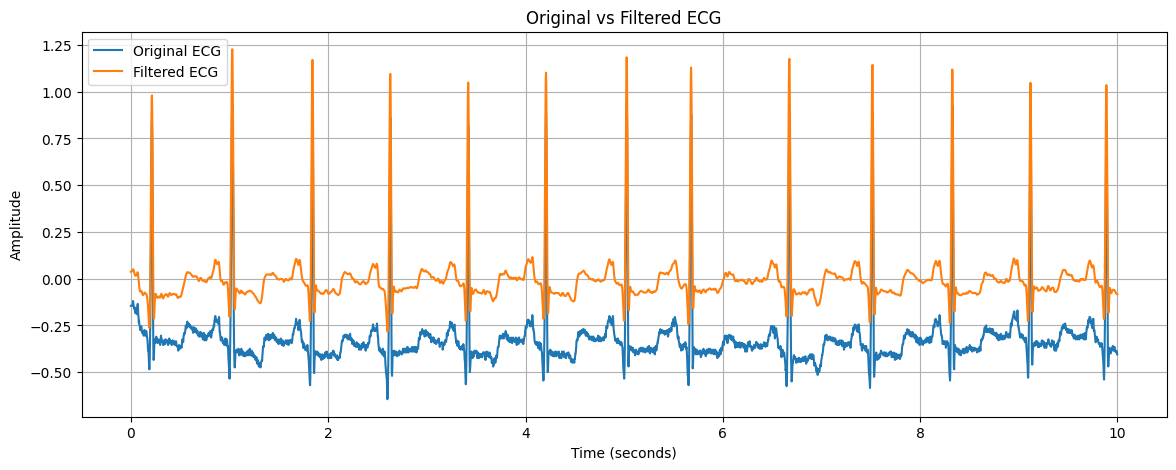

In [ ]:
#  Compare ECG before and after filtering

samples = int(10 * fs)

time = np.arange(samples) / fs

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    ecg[:samples],
    label="Original ECG"
)

plt.plot(
    time,
    filtered_ecg[:samples],
    label="Filtered ECG"
)

plt.title("Original vs Filtered ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Dataset manifest

manifest = {
    "project": "Multimodal Medical Data Ingestion",
    "datasets": {
        "tabular": {
            "name": "UCI Cleveland Heart Disease",
            "records": int(df_heart.shape[0]),
            "features": int(df_heart.shape[1])
        },

        "signal": {
            "name": "MIT-BIH Arrhythmia Database",
            "record": "100",
            "sampling_frequency": float(record.fs),
            "channels": int(record.n_sig)
        },

        "text": {
            "name": "Synthetic Clinical Note",
            "patient_id": patient_id
        },

        "image": {
            "name": "Synthetic Medical Image",
            "format": loaded_image.format,
            "size": loaded_image.size
        }
    }
}

with open(
    "/content/dataset_manifest.json",
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )

print("Manifest created successfully!")

print(
    json.dumps(
        manifest,
        indent=4
    )
)

Manifest created successfully!
{
    "project": "Multimodal Medical Data Ingestion",
    "datasets": {
        "tabular": {
            "name": "UCI Cleveland Heart Disease",
            "records": 303,
            "features": 15
        },
        "signal": {
            "name": "MIT-BIH Arrhythmia Database",
            "record": "100",
            "sampling_frequency": 360.0,
            "channels": 2
        },
        "text": {
            "name": "Synthetic Clinical Note",
            "patient_id": "P001"
        },
        "image": {
            "name": "Synthetic Medical Image",
            "format": "PNG",
            "size": [
                3000,
                2919
            ]
        }
    }
}


In [ ]:
#  Final summary

print("=" * 70)
print("MULTIMODAL MEDICAL DATA INGESTION - FINAL SUMMARY")
print("=" * 70)

print("\n1. TABULAR DATA")
print("   Dataset: UCI Cleveland Heart Disease")
print("   Records:", df_heart.shape[0])
print("   Features:", df_heart.shape[1])

print("\n2. SIGNAL DATA")
print("   Dataset: MIT-BIH Arrhythmia Database")
print("   Record: 100")
print("   Sampling Frequency:", record.fs, "Hz")
print("   Channels:", record.n_sig)

print("\n3. TEXT DATA")
print("   Type: Synthetic Clinical Note")
print("   Number of words:", len(clinical_note.split()))

print("\n4. IMAGE DATA")
print("   Type: Synthetic Medical Image")
print("   Size:", loaded_image.size)
print("   Mode:", loaded_image.mode)

print("\n5. MACHINE LEARNING")
print("   Model: Logistic Regression")
print("   Accuracy:", round(accuracy, 4))
print("   ROC-AUC:", round(auc, 4))

print("\n6. MULTIMODAL INTEGRATION")
print("   Patient ID:", patient_id)
print("   Modalities: Tabular + Text + Image + ECG Signal")

print("\nPipeline completed successfully!")

MULTIMODAL MEDICAL DATA INGESTION - FINAL SUMMARY

1. TABULAR DATA
   Dataset: UCI Cleveland Heart Disease
   Records: 303
   Features: 15

2. SIGNAL DATA
   Dataset: MIT-BIH Arrhythmia Database
   Record: 100
   Sampling Frequency: 360 Hz
   Channels: 2

3. TEXT DATA
   Type: Synthetic Clinical Note
   Number of words: 51

4. IMAGE DATA
   Type: Synthetic Medical Image
   Size: (3000, 2919)
   Mode: P

5. MACHINE LEARNING
   Model: Logistic Regression
   Accuracy: 0.8689
   ROC-AUC: 0.9513

6. MULTIMODAL INTEGRATION
   Patient ID: P001
   Modalities: Tabular + Text + Image + ECG Signal

Pipeline completed successfully!
